# Likelihood ratio scoring between User and Assistant models

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SCORES_PATH = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/scores/lratio_output_scores_20260203_113958.jsonl"

rows = []
with open(SCORES_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
#df.head()


In [2]:
# Keep only generation_match rows 
if "context_mode" in df.columns:
    df = df[df["context_mode"] == "generation_match"].copy()

df["user_turn"] = (df["target_user_msg_idx"] // 2).astype(int)  # 1,2,3,...

# Use token count for weighting
# Prefer n_tokens_user_role if available, else fallback to n_tokens_assistant_role
if "n_tokens_user_role" in df.columns:
    df["n_tok"] = df["n_tokens_user_role"]
else:
    df["n_tok"] = df["n_tokens_assistant_role"]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["llr_avg_logprob", "n_tok", "condition", "user_turn"])
df["n_tok"] = df["n_tok"].astype(int)

df[["conversation_id","condition","target_user_msg_idx","user_turn","llr_avg_logprob","n_tok"]].head()


,conversation_id,condition,target_user_msg_idx,user_turn,llr_avg_logprob,n_tok
0,ea2031b6-2cd7-4342-85ce-b34b26f079e2,no_persona,2,1,0.547852,33
1,ea2031b6-2cd7-4342-85ce-b34b26f079e2,no_persona,4,2,0.510742,44
2,ea2031b6-2cd7-4342-85ce-b34b26f079e2,no_persona,6,3,0.255859,53
3,ea2031b6-2cd7-4342-85ce-b34b26f079e2,no_persona,8,4,0.351562,65
4,ea2031b6-2cd7-4342-85ce-b34b26f079e2,no_persona,10,5,1.172852,64


/tmp/ipykernel_1856691/2861085291.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


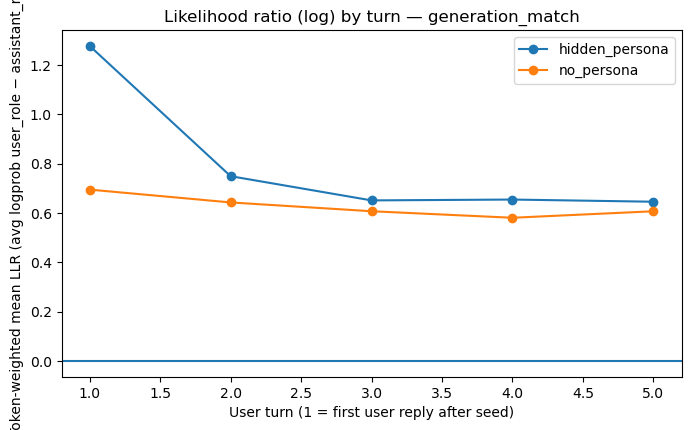

,condition,user_turn,llr_wmean,count,tok_total
0,hidden_persona,1,1.277115,250.0,11205.0
1,hidden_persona,2,0.749158,250.0,13333.0
2,hidden_persona,3,0.651018,250.0,13699.0
3,hidden_persona,4,0.654444,250.0,13783.0
4,hidden_persona,5,0.645645,250.0,13526.0
5,no_persona,1,0.694736,250.0,8615.0
6,no_persona,2,0.642745,250.0,10113.0
7,no_persona,3,0.607061,250.0,10895.0
8,no_persona,4,0.580625,250.0,11197.0
9,no_persona,5,0.606932,250.0,11175.0


In [3]:
def token_weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(x * w) / np.sum(w) if np.sum(w) > 0 else np.nan

# Aggregate by condition and user_turn
agg = (
    df.groupby(["condition", "user_turn"])
      .apply(lambda g: pd.Series({
          "llr_wmean": token_weighted_mean(g["llr_avg_logprob"], g["n_tok"]),
          "count": len(g),
          "tok_total": int(g["n_tok"].sum()),
      }))
      .reset_index()
      .sort_values(["condition","user_turn"])
)

plt.figure(figsize=(8,4.5))
for cond, g in agg.groupby("condition"):
    plt.plot(g["user_turn"], g["llr_wmean"], marker="o", label=cond)

plt.axhline(0.0)
plt.xlabel("User turn (1 = first user reply after seed)")
plt.ylabel("Token-weighted mean LLR (avg logprob user_role − assistant_role)")
plt.title("Likelihood ratio (log) by turn — generation_match")
plt.legend()
plt.show()

agg


`torch_dtype` is deprecated! Use `dtype` instead!
2026-02-03 18:46:39.809040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770140799.824936 1856691 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770140799.828908 1856691 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770140799.838851 1856691 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770140799.838858 1856691 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770140799.838859 1856691

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Total pairs found: 250


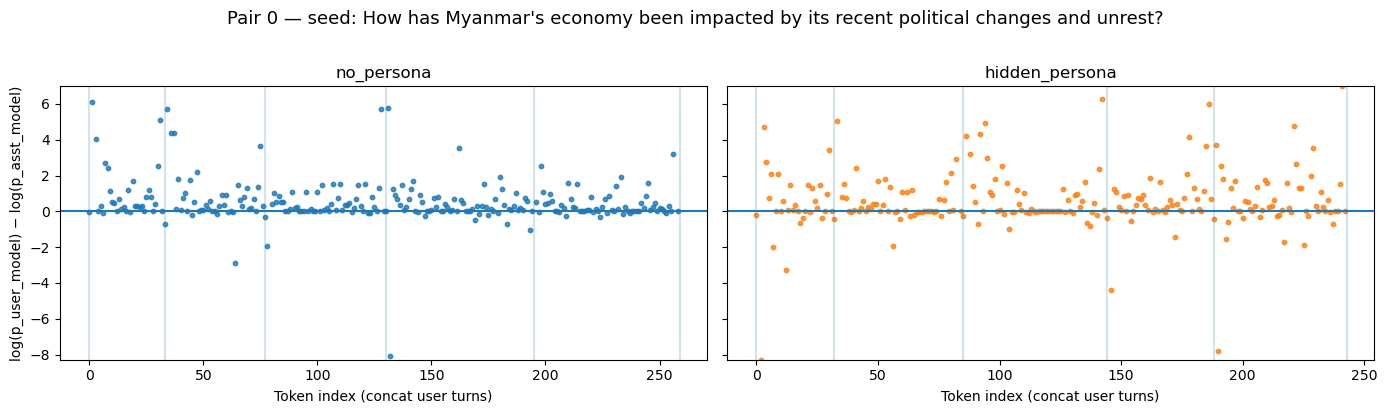

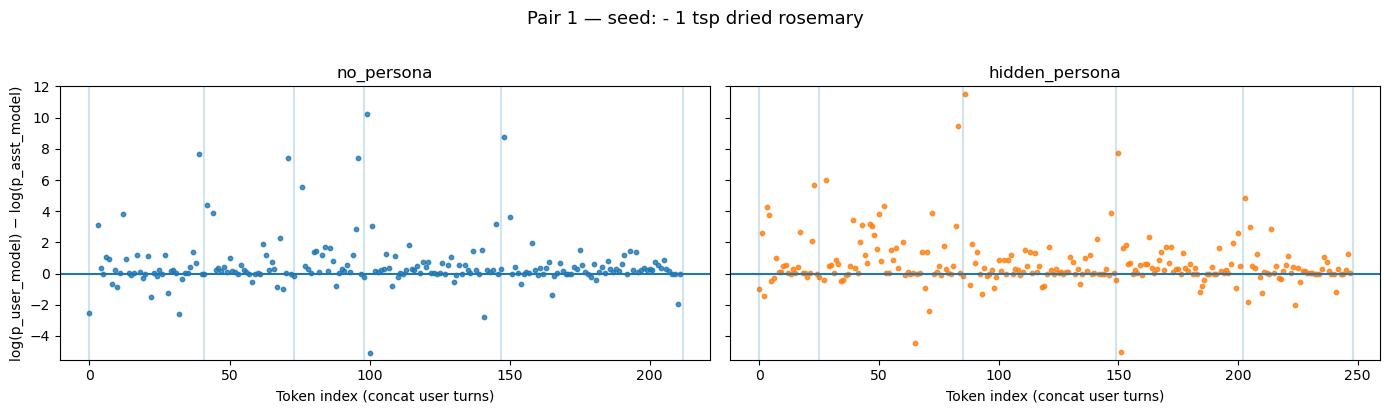

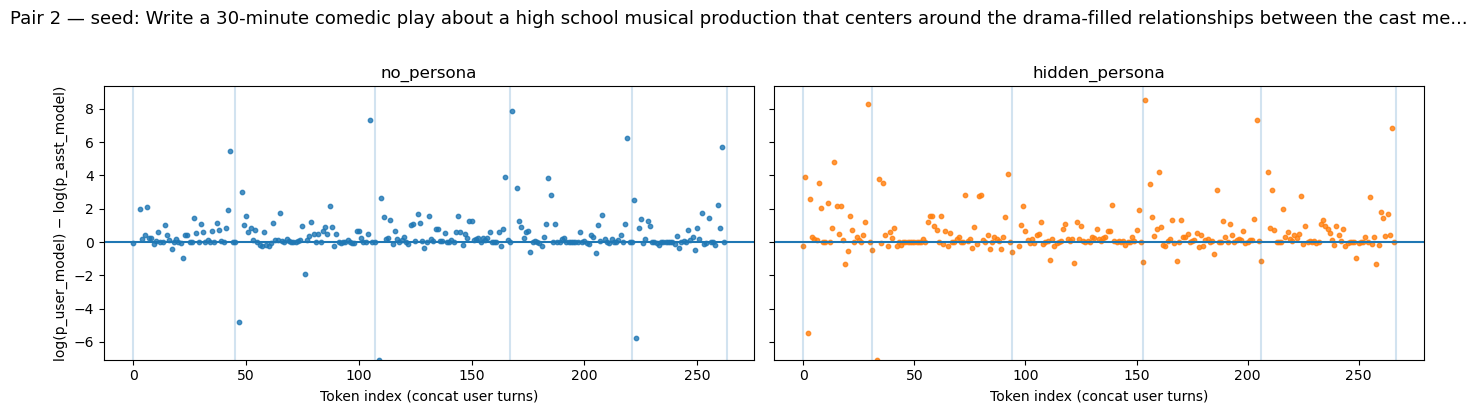

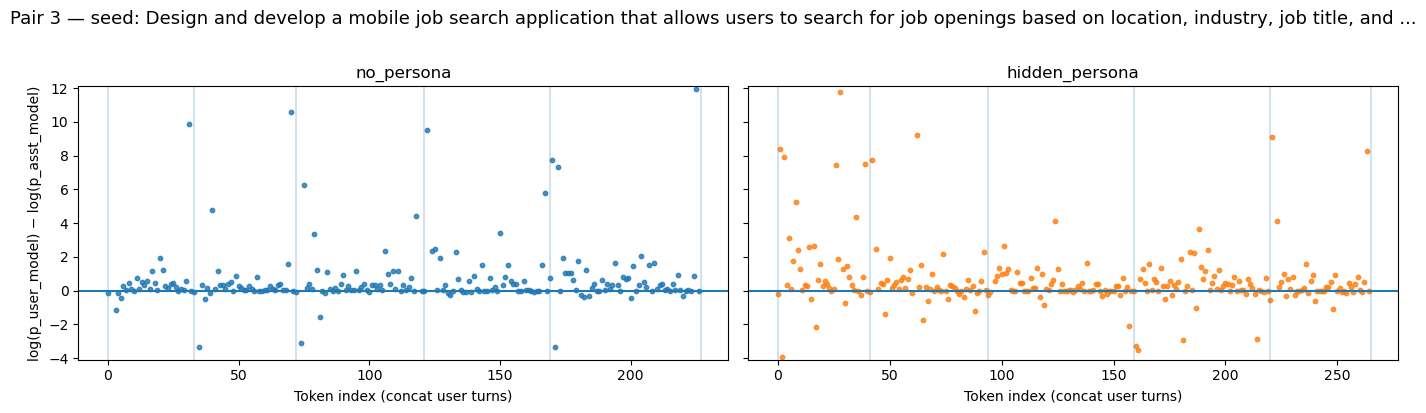

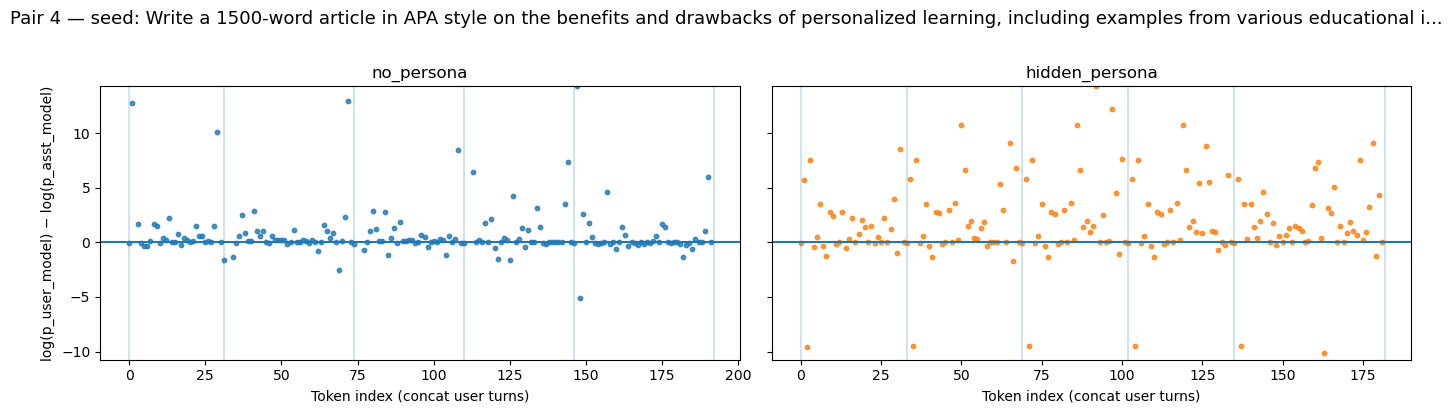

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

# -------------------------
# CONFIG (edit)
# -------------------------
CONVS_PATH = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/conversations/llm_vs_llm_conversations_20260127_212002.jsonl"  
MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

N_PAIRS = 5
PAIR_START_INDEX = 0          # which pairs to start from
MAX_USER_TURNS = None         # e.g. 6 if you want
POINT_SIZE = 10
BOUNDARY_ALPHA = 0.20
Y_LIM_PERCENTILES = (1, 99)   # robust scaling within each pair
FIXED_YLIM = None             # e.g. (-3, 8) to force a fixed y-scale across all figures

COLOR_NO = "tab:blue"
COLOR_HI = "tab:orange"

# -------------------------
# PROMPTS (match generator)
# -------------------------
ASSISTANT_SYSTEM_PROMPT = "You are a helpful assistant."
USER_SYSTEM_PROMPT = (
    "Respond as a user reacting naturally to the assistant’s last message.\n\n"
    "Your response should be short (1–2 sentences) and conversational.\n"
    "You may:\n"
    "- ask for clarification\n"
    "- request a change or refinement\n"
    "- express agreement or disagreement\n"
    "- ask a follow-up question\n\n"
    "Do NOT:\n"
    "- continue the assistant’s answer\n"
    "- add new content or solutions\n"
    "- restate the original task\n\n"
    "Write only the user’s next message."
)

def build_user_context_prompt(condition, persona_text, base_user_prompt=USER_SYSTEM_PROMPT):
    if condition == "hidden_persona" and persona_text:
        return (
            f"{base_user_prompt}\n\n"
            "=== INTERNAL CHARACTER NOTES (DO NOT MENTION THESE) ===\n"
            f"{persona_text}\n\n"
            "CRITICAL INSTRUCTIONS:\n"
            "- These are background facts about you as a person\n"
            "- They should SUBTLY influence your tone, interests, and reactions\n"
            "- DO NOT explicitly reference these facts unless the assistant directly asks about them\n"
            "- NEVER say things like 'my girlfriend' or 'I make 50k' unprompted\n"
            "- Stay focused on reacting to what the ASSISTANT just said\n"
        )
    return base_user_prompt

# -------------------------
# Model helpers
# -------------------------
def load_model(model_name):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )
    model.eval()
    return model, tok

def apply_chat_template(tok, messages):
    return tok.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
        return_tensors="pt",
    )

def generation_match_context(messages, user_idx):
    # user sees only system + last assistant message (per your generator)
    if user_idx - 1 >= 0 and messages[user_idx - 1].get("role") == "assistant":
        return [{"role": "assistant", "content": messages[user_idx - 1].get("content", "")}]
    return []

@torch.no_grad()
def token_logprobs_for_target(model, tok, system_prompt, context_messages, target_user_text, prepend_system=True):
    ctx = list(context_messages)
    if prepend_system:
        ctx = [{"role": "system", "content": system_prompt}] + ctx
    full = ctx + [{"role": "user", "content": target_user_text}]

    ctx_ids = apply_chat_template(tok, ctx).to(model.device)
    full_ids = apply_chat_template(tok, full).to(model.device)

    Lc = ctx_ids.shape[1]
    L = full_ids.shape[1]
    if L <= Lc:
        return np.array([])

    logits = model(full_ids).logits
    start = max(Lc - 1, 0)
    end = L - 1

    logits_slice = logits[0, start:end, :]
    target_ids = full_ids[0, Lc:L]

    log_probs = F.log_softmax(logits_slice, dim=-1)
    token_lp = log_probs.gather(1, target_ids.unsqueeze(1)).squeeze(1)
    return token_lp.detach().float().cpu().numpy()

def compute_concat_token_llr(conv, model, tok, max_user_turns=None):
    messages = conv["messages"]

    # repair possible generator typo "ontent"
    for m in messages:
        if "content" not in m and "ontent" in m:
            m["content"] = m["ontent"]

    condition = conv.get("condition", "")
    persona_text = conv.get("persona_text")

    user_sys = build_user_context_prompt(condition, persona_text)
    asst_sys = ASSISTANT_SYSTEM_PROMPT

    user_indices = [i for i,m in enumerate(messages) if m.get("role") == "user"][1:]  # skip seed
    if max_user_turns is not None:
        user_indices = user_indices[:max_user_turns]

    segs = []
    boundaries = [0]
    offset = 0

    for ui in user_indices:
        ctx = generation_match_context(messages, ui)
        target_text = messages[ui].get("content", "")

        lp_user = token_logprobs_for_target(model, tok, user_sys, ctx, target_text)
        lp_asst = token_logprobs_for_target(model, tok, asst_sys, ctx, target_text)

        if len(lp_user) == 0 or len(lp_user) != len(lp_asst):
            continue

        llr = lp_user - lp_asst
        segs.append(llr)

        offset += len(llr)
        boundaries.append(offset)

    if not segs:
        return None, None

    return np.concatenate(segs), boundaries

# -------------------------
# Pair loader
# -------------------------
def load_pairs_by_seed(jsonl_path):
    by_seed = {}
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            c = json.loads(line)
            seed = c.get("seed_prompt")
            cond = c.get("condition")
            if seed is None or cond is None:
                continue
            by_seed.setdefault(seed, {})[cond] = c

    pairs = [(seed, d["no_persona"], d["hidden_persona"])
             for seed, d in by_seed.items()
             if "no_persona" in d and "hidden_persona" in d]
    return pairs

# -------------------------
# Plot one pair (side-by-side)
# -------------------------
def plot_pair_side_by_side(pair_idx, seed, conv_no, conv_hi, model, tok):
    y_no, b_no = compute_concat_token_llr(conv_no, model, tok, max_user_turns=MAX_USER_TURNS)
    y_hi, b_hi = compute_concat_token_llr(conv_hi, model, tok, max_user_turns=MAX_USER_TURNS)

    if y_no is None or y_hi is None:
        print(f"Pair {pair_idx}: skipping (missing/mismatch)")
        return

    # y-lims: fixed, or robust within this pair
    if FIXED_YLIM is not None:
        ylim = FIXED_YLIM
    else:
        all_y = np.concatenate([y_no, y_hi])
        lo, hi = np.percentile(all_y, Y_LIM_PERCENTILES)
        lo = min(lo, 0.0)
        hi = max(hi, 0.0)
        ylim = (lo, hi)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    # Figure title shows the seed ONCE
    seed_short = seed[:140] + ("..." if len(seed) > 140 else "")
    fig.suptitle(f"Pair {pair_idx} — seed: {seed_short}", y=1.02, fontsize=13)

    # Left: no_persona
    ax = axes[0]
    x = np.arange(len(y_no))
    ax.scatter(x, y_no, s=POINT_SIZE, alpha=0.8, color=COLOR_NO)
    ax.axhline(0.0)
    for b in b_no:
        ax.axvline(b, alpha=BOUNDARY_ALPHA)
    ax.set_title("no_persona")
    ax.set_xlabel("Token index (concat user turns)")
    ax.set_ylabel("log(p_user_model) − log(p_asst_model)")
    ax.set_ylim(*ylim)
    #ax.text(0.01, 0.02, f"id: {conv_no.get('conversation_id')}", transform=ax.transAxes, fontsize=9, va="bottom")

    # Right: hidden_persona
    ax = axes[1]
    x = np.arange(len(y_hi))
    ax.scatter(x, y_hi, s=POINT_SIZE, alpha=0.8, color=COLOR_HI)
    ax.axhline(0.0)
    for b in b_hi:
        ax.axvline(b, alpha=BOUNDARY_ALPHA)
    ax.set_title("hidden_persona")
    ax.set_xlabel("Token index (concat user turns)")
    ax.set_ylim(*ylim)
    #ax.text(0.01, 0.02, f"id: {conv_hi.get('conversation_id')}", transform=ax.transAxes, fontsize=9, va="bottom")

    plt.tight_layout()
    plt.show()

# -------------------------
# RUN: plot N_PAIRS figures
# -------------------------
model, tok = load_model(MODEL_NAME)
pairs = load_pairs_by_seed(CONVS_PATH)
print("Total pairs found:", len(pairs))

start = PAIR_START_INDEX
end = min(start + N_PAIRS, len(pairs))

for i in range(start, end):
    seed, conv_no, conv_hi = pairs[i]
    plot_pair_side_by_side(i, seed, conv_no, conv_hi, model, tok)
